# Métodos de reducción de dimensionalidad

## Análisis de componentes principales (ACP)

In [1]:
# Análisis de componentes principales (ACP)

import pandas as pd
import numpy as np

from google.colab import files
uploaded = files.upload()

# Datos: World Development Indicators
wdi = (
    pd.read_excel("WDI.xlsx")
      .set_index("Country")
)

wdi["Income"] = pd.Categorical(
    wdi["Income"],
    categories=["Low income", "Lower middle income", "Upper middle income", "High income"],
    ordered=True
).rename_categories(["Low", "Lower middle", "Upper middle", "High"])

wdi["Region"] = wdi["Region"].astype("category")

# Casos completos (sin faltantes)
datos = wdi.dropna()  # eliminando individuos con faltantes
print(datos.shape)

# Vista rápida
print(wdi.head())


Saving WDI.xlsx to WDI.xlsx
(97, 10)
                            Region        Income  Inflation           GDP  \
Country                                                                     
ABW      Latin America & Caribbean          High   3.626041  30918.483584   
AFG                     South Asia           Low   0.626149    492.090632   
AGO             Sub-Saharan Africa  Lower middle  19.630594   2540.508878   
ALB          Europe & Central Asia  Upper middle   2.028060   5287.660801   
AND          Europe & Central Asia          High        NaN  42904.811588   

         Education  Sanitation     Health   Labor  Mortality   Urban  
Country                                                               
ABW            NaN   98.682384        NaN     NaN        NaN  43.411  
AFG            NaN   49.234144  14.208419     NaN       47.8  25.495  
AGO       2.044701   51.120744   2.588796     NaN       52.0  65.514  
ALB       3.152945   98.973646   6.659588  59.296        8.3  60.319

In [2]:
# Matriz estandarizada y ponderada
Z = datos.select_dtypes(include=[np.number])
Z = Z.apply(lambda x: (x - x.mean()) / (x.std(ddof=1) * np.sqrt(len(x) - 1)))
Z = Z.to_numpy()


In [3]:
# DVS (Z = P%*%D%*%t(Q))
dvs = np.linalg.svd(Z, full_matrices=False)
D = np.diag(dvs[1])
print(pd.DataFrame(D))

          0         1         2         3         4     5         6         7
0  1.849196  0.000000  0.000000  0.000000  0.000000  0.00  0.000000  0.000000
1  0.000000  1.109975  0.000000  0.000000  0.000000  0.00  0.000000  0.000000
2  0.000000  0.000000  1.011766  0.000000  0.000000  0.00  0.000000  0.000000
3  0.000000  0.000000  0.000000  0.957374  0.000000  0.00  0.000000  0.000000
4  0.000000  0.000000  0.000000  0.000000  0.746859  0.00  0.000000  0.000000
5  0.000000  0.000000  0.000000  0.000000  0.000000  0.63  0.000000  0.000000
6  0.000000  0.000000  0.000000  0.000000  0.000000  0.00  0.611889  0.000000
7  0.000000  0.000000  0.000000  0.000000  0.000000  0.00  0.000000  0.281227


In [4]:
# Valores propios de Rx
lamb = dvs[1]**2
print(lamb)


[3.41952411 1.23204392 1.02367091 0.91656561 0.55779843 0.39689998
 0.37440841 0.07908863]


In [5]:
# Vectores propios de Z*t(Z)
P = dvs[0]
print(pd.DataFrame(P[:10, :]))  # primeras filas de P


          0         1         2         3         4         5         6  \
0  0.009147  0.111882  0.055609  0.024680 -0.043653 -0.024128  0.069200   
1 -0.014549  0.104394 -0.021529 -0.024797  0.055495 -0.219798  0.256057   
2 -0.133189 -0.036083 -0.030928  0.021583  0.083946 -0.049931 -0.014648   
3 -0.093590 -0.034008  0.000061  0.066930 -0.031960 -0.173852 -0.094277   
4  0.059681  0.174278 -0.039472 -0.048550  0.032987  0.023185  0.012967   
5 -0.138770 -0.127316  0.091745  0.097630 -0.002441  0.078985  0.018492   
6  0.230675 -0.023408 -0.185955  0.131530  0.201272  0.126129  0.064338   
7  0.224497 -0.189166 -0.004830  0.258386 -0.039674  0.077157 -0.071440   
8 -0.006391  0.021436  0.094722  0.049269 -0.019984  0.069420  0.085484   
9 -0.035327  0.023872 -0.048488 -0.180912 -0.059690  0.107638  0.047300   

          7  
0 -0.044028  
1  0.031490  
2 -0.012810  
3  0.021396  
4 -0.169916  
5 -0.064447  
6  0.115089  
7  0.094015  
8  0.120804  
9  0.010515  


In [6]:
# Vectores propios de t(Z)*Z
Q = dvs[2].T
print(pd.DataFrame(Q))

          0         1         2         3         4         5         6  \
0  0.186396 -0.316798  0.494299 -0.700263  0.234016 -0.206175 -0.164097   
1 -0.416570 -0.110277 -0.122713  0.226757  0.515120 -0.142039 -0.679861   
2 -0.206236 -0.687834 -0.216357 -0.113052 -0.539741  0.272713 -0.227874   
3 -0.429120  0.376504  0.248991 -0.216042 -0.276905 -0.117808 -0.110200   
4 -0.390310 -0.371324  0.111804  0.221850 -0.004639 -0.641374  0.484346   
5 -0.151499  0.135764 -0.748502 -0.563595  0.135063 -0.189775  0.160315   
6  0.457181 -0.317041 -0.195045  0.147998  0.318810 -0.056334  0.098771   
7 -0.425135 -0.125612  0.144931 -0.099985  0.438164  0.631282  0.420409   

          7  
0  0.077432  
1  0.009864  
2 -0.084496  
3 -0.680243  
4  0.045665  
5  0.027649  
6 -0.718301  
7 -0.072327  


In [7]:
# Componentes principales
F = pd.DataFrame(Z @ Q, index=datos.index)
F.columns = [f"CP{i+1}" for i in range(F.shape[1])]
print(F.head())  # primears filas de F


              CP1       CP2       CP3       CP4       CP5       CP6       CP7  \
Country                                                                         
ALB      0.016914  0.124186  0.056263  0.023628 -0.032603 -0.015200  0.042343   
ARM     -0.026904  0.115875 -0.021783 -0.023740  0.041447 -0.138472  0.156679   
AUS     -0.246293 -0.040051 -0.031292  0.020663  0.062696 -0.031457 -0.008963   
AUT     -0.173066 -0.037748  0.000062  0.064077 -0.023870 -0.109527 -0.057687   
AZE      0.110362  0.193444 -0.039937 -0.046481  0.024636  0.014606  0.007934   

              CP8  
Country            
ALB     -0.012382  
ARM      0.008856  
AUS     -0.003603  
AUT      0.006017  
AZE     -0.047785  


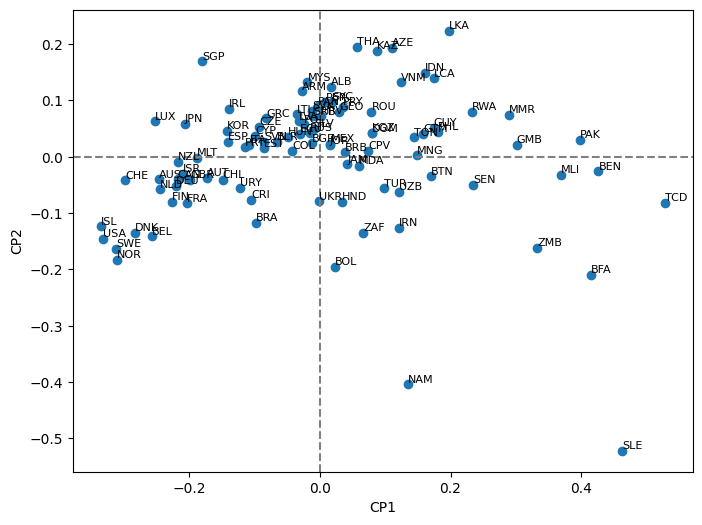

In [8]:
# Primer plano principal
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(F["CP1"], F["CP2"])

for i, label in enumerate(F.index):
    plt.text(F["CP1"].iloc[i], F["CP2"].iloc[i], label,
             fontsize=8, va="bottom")

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")
plt.xlabel("CP1")
plt.ylabel("CP2")
plt.show()


In [9]:
# Correlaciones entre componentes y variables
Rcv = pd.DataFrame(
    np.corrcoef(Z.T, F.T)[:Z.shape[1], Z.shape[1]:],
    index=datos.select_dtypes(include=[np.number]).columns,
    columns=F.columns
)
print(Rcv)


                 CP1       CP2       CP3       CP4       CP5       CP6  \
Inflation   0.344682 -0.351638  0.500115 -0.670414  0.174777 -0.129890   
GDP        -0.770319 -0.122404 -0.124157  0.217091  0.384722 -0.089485   
Education  -0.381371 -0.763479 -0.218903 -0.108234 -0.403111  0.171809   
Sanitation -0.793527  0.417910  0.251921 -0.206833 -0.206809 -0.074219   
Health     -0.721760 -0.412160  0.113120  0.212394 -0.003464 -0.404066   
Labor      -0.280150  0.150695 -0.757309 -0.539572  0.100873 -0.119558   
Mortality   0.845417 -0.351907 -0.197340  0.141689  0.238106 -0.035490   
Urban      -0.786159 -0.139426  0.146637 -0.095724  0.327246  0.397708   

                 CP7       CP8  
Inflation  -0.100409  0.021776  
GDP        -0.415999  0.002774  
Education  -0.139433 -0.023763  
Sanitation -0.067430 -0.191303  
Health      0.296366  0.012842  
Labor       0.098095  0.007776  
Mortality   0.060437 -0.202006  
Urban       0.257244 -0.020340  


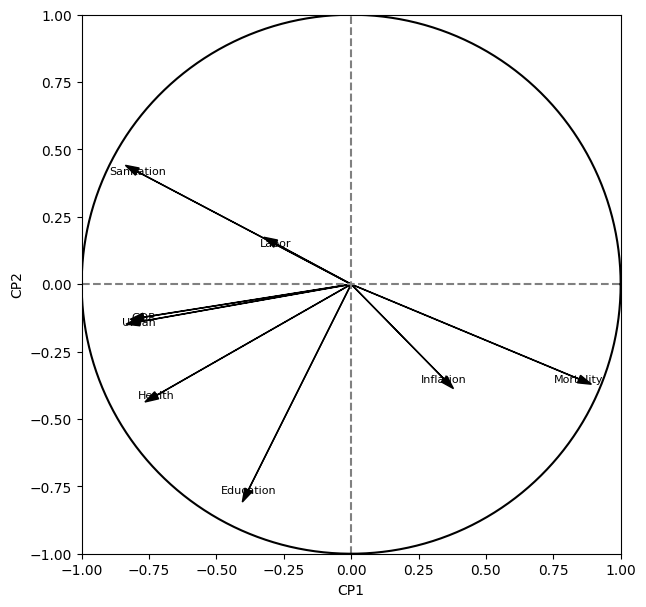

In [10]:
# Primer plano principal (k=1 y l=2)
plt.figure(figsize=(7, 7))

for i, label in enumerate(Rcv.index):
    x, y = Rcv.iloc[i, 0], Rcv.iloc[i, 1]
    plt.arrow(0, 0, x, y,
              head_width=0.03, head_length=0.05, fc="black", ec="black")
    plt.text(x, y, label, ha="center", va="center", fontsize=8)

plt.axhline(0, linestyle="--", color="gray")
plt.axvline(0, linestyle="--", color="gray")

theta = np.linspace(0, 2*np.pi, 200)
plt.plot(np.cos(theta), np.sin(theta), color="black")

plt.xlim(-1, 1)
plt.ylim(-1, 1)
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("CP1")
plt.ylabel("CP2")
plt.show()


In [11]:
# cos2 de las variables
cos2v = Rcv**2
print(cos2v)

                 CP1       CP2       CP3       CP4       CP5       CP6  \
Inflation   0.118806  0.123649  0.250115  0.449455  0.030547  0.016872   
GDP         0.593392  0.014983  0.015415  0.047129  0.148011  0.008008   
Education   0.145444  0.582900  0.047918  0.011714  0.162498  0.029518   
Sanitation  0.629685  0.174649  0.063464  0.042780  0.042770  0.005508   
Health      0.520938  0.169876  0.012796  0.045111  0.000012  0.163269   
Labor       0.078484  0.022709  0.573517  0.291138  0.010175  0.014294   
Mortality   0.714729  0.123839  0.038943  0.020076  0.056695  0.001260   
Urban       0.618045  0.019440  0.021502  0.009163  0.107090  0.158171   

                 CP7       CP8  
Inflation   0.010082  0.000474  
GDP         0.173055  0.000008  
Education   0.019442  0.000565  
Sanitation  0.004547  0.036597  
Health      0.087833  0.000165  
Labor       0.009623  0.000060  
Mortality   0.003653  0.040806  
Urban       0.066174  0.000414  


In [12]:
# cos2 de los individuos
cos2i = (F**2).div((F**2).sum(axis=1), axis=0)
print(cos2i.head(10))  # primeras filas


              CP1       CP2           CP3       CP4       CP5       CP6  \
Country                                                                   
ALB      0.012618  0.680222  1.396201e-01  0.024624  0.046883  0.010191   
ARM      0.011923  0.221174  7.815943e-03  0.009283  0.028297  0.315850   
AUS      0.883178  0.023355  1.425623e-02  0.006216  0.057229  0.014407   
AUT      0.582579  0.027715  7.511704e-08  0.079862  0.011082  0.233330   
AZE      0.215484  0.662050  2.821770e-02  0.038223  0.010738  0.003775   
BEL      0.620589  0.188207  8.120295e-02  0.082333  0.000031  0.023335   
BEN      0.685607  0.002544  1.333790e-01  0.059748  0.085144  0.023792   
BFA      0.607914  0.155512  8.423514e-05  0.215852  0.003097  0.008335   
BGR      0.007700  0.031207  5.062912e-01  0.122645  0.012280  0.105436   
BLR      0.095243  0.015669  5.371280e-02  0.669502  0.044354  0.102628   

              CP7       CP8  
Country                      
ALB      0.079080  0.006762  
ARM      

In [13]:
# Contribuciones de las variables
ctrv = (Rcv**2).div((Rcv**2).sum(axis=0), axis=1)
print(ctrv)


                 CP1       CP2       CP3       CP4       CP5       CP6  \
Inflation   0.034743  0.100361  0.244332  0.490368  0.054764  0.042508   
GDP         0.173531  0.012161  0.015059  0.051419  0.265348  0.020175   
Education   0.042533  0.473116  0.046810  0.012781  0.291321  0.074372   
Sanitation  0.184144  0.141755  0.061997  0.046674  0.076676  0.013879   
Health      0.152342  0.137882  0.012500  0.049218  0.000022  0.411361   
Labor       0.022952  0.018432  0.560255  0.317640  0.018242  0.036014   
Mortality   0.209014  0.100515  0.038043  0.021903  0.101640  0.003174   
Urban       0.180740  0.015778  0.021005  0.009997  0.191987  0.398517   

                 CP7       CP8  
Inflation   0.026928  0.005996  
GDP         0.462210  0.000097  
Education   0.051926  0.007140  
Sanitation  0.012144  0.462731  
Health      0.234591  0.002085  
Labor       0.025701  0.000764  
Mortality   0.009756  0.515956  
Urban       0.176744  0.005231  


In [14]:
# Contribuciones de los individuos
ctri = (F**2).div((F**2).sum(axis=0), axis=1)
print(ctri.head(10))  # primeras filas


              CP1       CP2           CP3       CP4       CP5       CP6  \
Country                                                                   
ALB      0.000084  0.012518  3.092314e-03  0.000609  0.001906  0.000582   
ARM      0.000212  0.010898  4.635188e-04  0.000615  0.003080  0.048311   
AUS      0.017739  0.001302  9.565325e-04  0.000466  0.007047  0.002493   
AUT      0.008759  0.001157  3.772646e-09  0.004480  0.001021  0.030224   
AZE      0.003562  0.030373  1.558055e-03  0.002357  0.001088  0.000538   
BEL      0.019257  0.016209  8.417164e-03  0.009532  0.000006  0.006239   
BEN      0.053211  0.000548  3.457940e-02  0.017300  0.040511  0.015909   
BFA      0.050399  0.035784  2.332811e-05  0.066763  0.001574  0.005953   
BGR      0.000041  0.000460  8.972283e-03  0.002427  0.000399  0.004819   
BLR      0.001248  0.000570  2.351068e-03  0.032729  0.003563  0.011586   

              CP7       CP8  
Country                      
ALB      0.004789  0.001938  
ARM      

In [15]:
# Inercia de cada componente
inercia = lamb / lamb.sum() * 100
print(inercia)


[42.74405138 15.40054895 12.79588636 11.45707011  6.97248043  4.96124977
  4.68010508  0.98860791]


In [16]:
# Inercia acumulada
inercia_acum = np.cumsum(inercia)
print(inercia_acum)


[ 42.74405138  58.14460033  70.9404867   82.39755681  89.37003724
  94.33128701  99.01139209 100.        ]


In [17]:
# Usando librerías

# ACP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = datos.select_dtypes(include=[np.number])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

acp = PCA(n_components=4)
acp.fit(X_scaled)


PCA(n_components=4)

In [18]:
# Valores propios y porcentajes de inercia
eig = pd.DataFrame({
    "v. propio": acp.explained_variance_,
    "inercia": acp.explained_variance_ratio_ * 100,
    "iner. acum.": np.cumsum(acp.explained_variance_ratio_ * 100)
})

print(eig)


   v. propio    inercia  iner. acum.
0   3.455144  42.744051    42.744051
1   1.244878  15.400549    58.144600
2   1.034334  12.795886    70.940487
3   0.926113  11.457070    82.397557


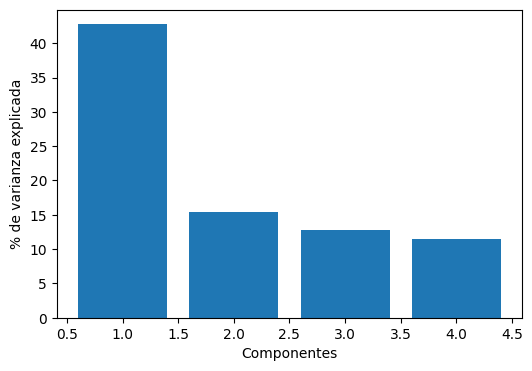

In [19]:
# Histograma de valores propios (Scree Plot)
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(range(1, len(acp.explained_variance_ratio_) + 1),
        acp.explained_variance_ratio_ * 100)

plt.xlabel("Componentes")
plt.ylabel("% de varianza explicada")
plt.show()


In [20]:
# Vectores propios (Q)
Q = pd.DataFrame(
    acp.components_.T,
    index=X.columns,
    columns=[f"CP{i+1}" for i in range(acp.components_.shape[0])]
)
print(Q)


                 CP1       CP2       CP3       CP4
Inflation   0.186396  0.316798 -0.494299  0.700263
GDP        -0.416570  0.110277  0.122713 -0.226757
Education  -0.206236  0.687834  0.216357  0.113052
Sanitation -0.429120 -0.376504 -0.248991  0.216042
Health     -0.390310  0.371324 -0.111804 -0.221850
Labor      -0.151499 -0.135764  0.748502  0.563595
Mortality   0.457181  0.317041  0.195045 -0.147998
Urban      -0.425135  0.125612 -0.144931  0.099985


In [21]:
# Correlaciones entre variables y componentes
var_cor = pd.DataFrame(
    acp.components_.T * np.sqrt(acp.explained_variance_),
    index=X.columns,
    columns=[f"CP{i+1}" for i in range(acp.components_.shape[0])]
)
print(var_cor)


                 CP1       CP2       CP3       CP4
Inflation   0.346473  0.353465 -0.502713  0.673897
GDP        -0.774321  0.123040  0.124802 -0.218219
Education  -0.383353  0.767445  0.220040  0.108796
Sanitation -0.797649 -0.420081 -0.253229  0.207908
Health     -0.725510  0.414301 -0.113707 -0.213497
Labor      -0.281606 -0.151478  0.761243  0.542375
Mortality   0.849808  0.353735  0.198365 -0.142426
Urban      -0.790243  0.140150 -0.147398  0.096221


In [22]:
# cos2 entre variables y componentes
var_cos2 = (var_cor**2).round(3)
print(var_cos2)


              CP1    CP2    CP3    CP4
Inflation   0.120  0.125  0.253  0.454
GDP         0.600  0.015  0.016  0.048
Education   0.147  0.589  0.048  0.012
Sanitation  0.636  0.176  0.064  0.043
Health      0.526  0.172  0.013  0.046
Labor       0.079  0.023  0.579  0.294
Mortality   0.722  0.125  0.039  0.020
Urban       0.624  0.020  0.022  0.009


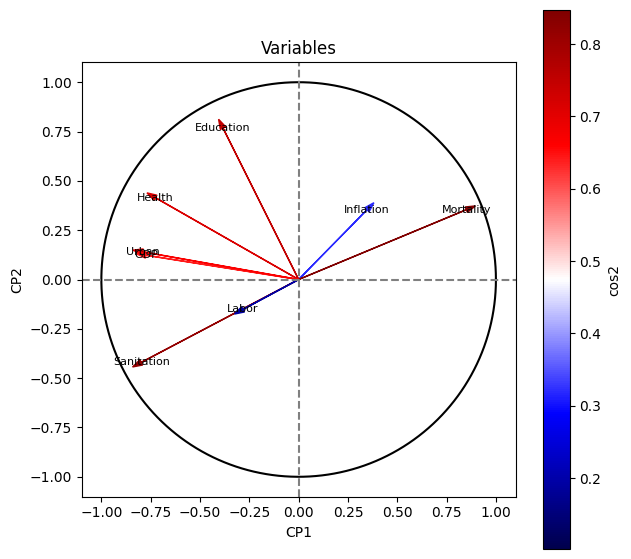

In [23]:
# Representación de las variables
# Componentes 1 y 2 coloreadas por cos2
fig, ax = plt.subplots(figsize=(7, 7))

colors = var_cos2["CP1"] + var_cos2["CP2"]

for i, label in enumerate(var_cor.index):
    x, y = var_cor["CP1"].iloc[i], var_cor["CP2"].iloc[i]
    color = plt.cm.seismic(colors.iloc[i] / colors.max())
    ax.arrow(0, 0, x, y,
             head_width=0.03, head_length=0.05,
             fc=color, ec=color)
    ax.text(x, y, label, fontsize=8, ha="center", va="center")

# círculo unitario
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black")

ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")
ax.set_xlabel("CP1")
ax.set_ylabel("CP2")
ax.set_title("Variables")
ax.set_aspect("equal", adjustable="box")

sm = plt.cm.ScalarMappable(cmap="seismic",
                           norm=plt.Normalize(vmin=colors.min(),
                                              vmax=colors.max()))
fig.colorbar(sm, ax=ax, label="cos2")

plt.show()


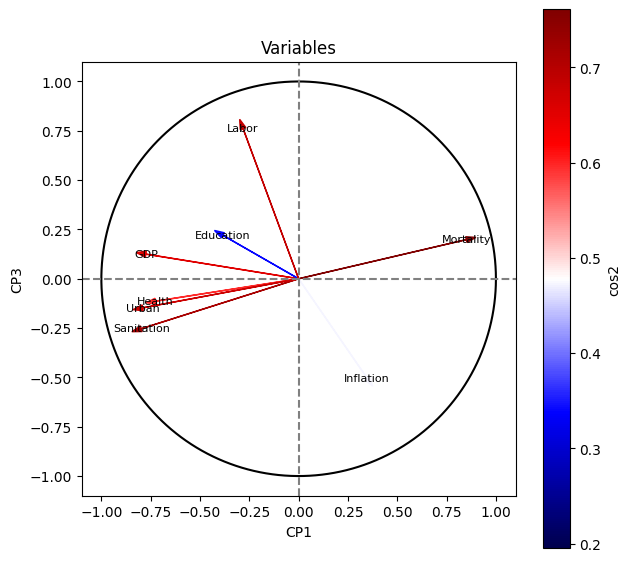

In [24]:
# Componentes 1 y 3
fig, ax = plt.subplots(figsize=(7, 7))

colors = var_cos2["CP1"] + var_cos2["CP3"]

for i, label in enumerate(var_cor.index):
    x, y = var_cor["CP1"].iloc[i], var_cor["CP3"].iloc[i]
    color = plt.cm.seismic(colors.iloc[i] / colors.max())
    ax.arrow(0, 0, x, y,
             head_width=0.03, head_length=0.05,
             fc=color, ec=color)
    ax.text(x, y, label, fontsize=8, ha="center", va="center")

# círculo unitario
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black")

ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")
ax.set_xlabel("CP1")
ax.set_ylabel("CP3")
ax.set_title("Variables")
ax.set_aspect("equal", adjustable="box")

sm = plt.cm.ScalarMappable(cmap="seismic",
                           norm=plt.Normalize(vmin=colors.min(),
                                              vmax=colors.max()))
fig.colorbar(sm, ax=ax, label="cos2")

plt.show()


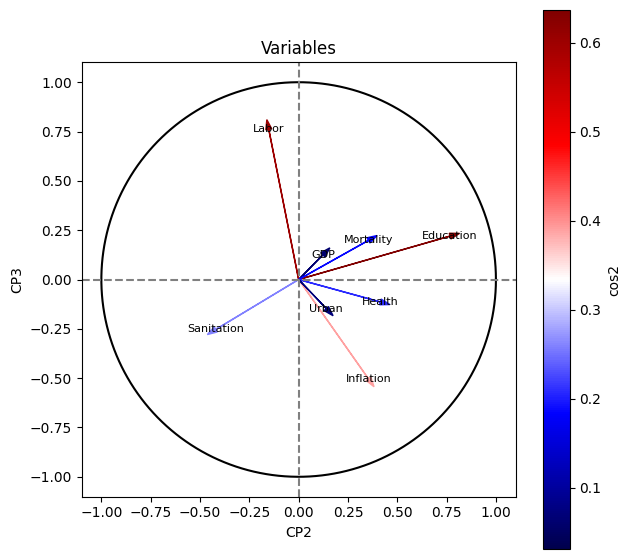

In [25]:
# Componentes 2 y 3
fig, ax = plt.subplots(figsize=(7, 7))

colors = var_cos2["CP2"] + var_cos2["CP3"]

for i, label in enumerate(var_cor.index):
    x, y = var_cor["CP2"].iloc[i], var_cor["CP3"].iloc[i]
    color = plt.cm.seismic(colors.iloc[i] / colors.max())
    ax.arrow(0, 0, x, y,
             head_width=0.03, head_length=0.05,
             fc=color, ec=color)
    ax.text(x, y, label, fontsize=8, ha="center", va="center")

# círculo unitario
theta = np.linspace(0, 2*np.pi, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black")

ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")
ax.set_xlabel("CP2")
ax.set_ylabel("CP3")
ax.set_title("Variables")
ax.set_aspect("equal", adjustable="box")

sm = plt.cm.ScalarMappable(cmap="seismic",
                           norm=plt.Normalize(vmin=colors.min(),
                                              vmax=colors.max()))
fig.colorbar(sm, ax=ax, label="cos2")

plt.show()


In [26]:
# Contribuciones de las variables
var_contrib = (var_cor**2).div((var_cor**2).sum(axis=0), axis=1) * 100
print(var_contrib)


                  CP1        CP2        CP3        CP4
Inflation    3.474342  10.036102  24.433179  49.036834
GDP         17.353057   1.216096   1.505856   5.141874
Education    4.253344  47.311617   4.681044   1.278086
Sanitation  18.414412  14.175516   6.199654   4.667434
Health      15.234221  13.788159   1.250013   4.921752
Labor        2.295180   1.843198  56.025488  31.763972
Mortality   20.901427  10.051475   3.804256   2.190340
Urban       18.074017   1.577838   2.100510   0.999709


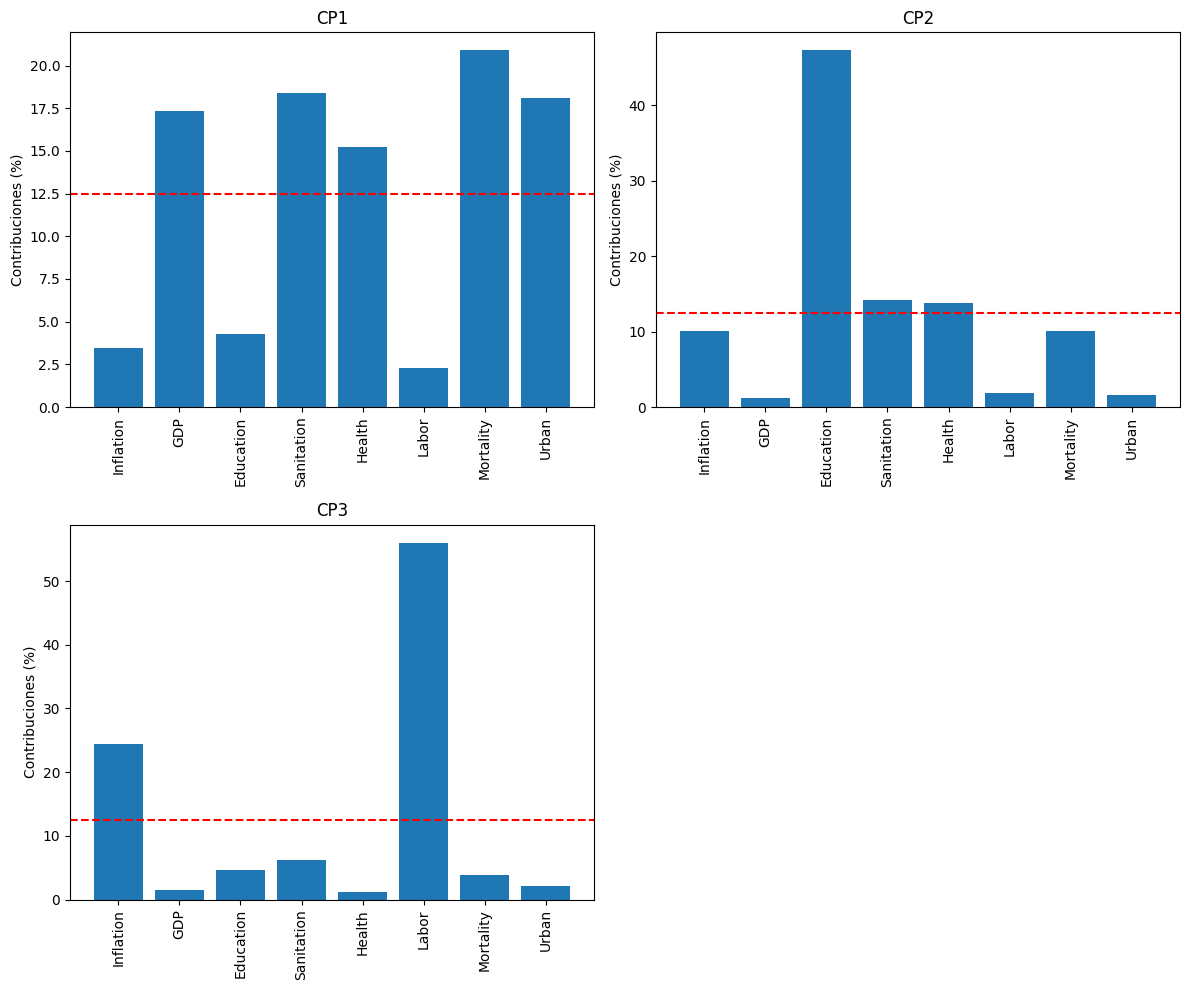

In [27]:
# Gráfico de contribuciones de las variables
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

p = var_contrib.shape[0]   # número de variables
ref = 100 / p              # línea de referencia en %

# CP1
axes[0, 0].bar(var_contrib.index, var_contrib["CP1"])
axes[0, 0].axhline(y=ref, color="red", linestyle="--")
axes[0, 0].set_title("CP1")
axes[0, 0].set_ylabel("Contribuciones (%)")
axes[0, 0].tick_params(axis='x', rotation=90)

# CP2
axes[0, 1].bar(var_contrib.index, var_contrib["CP2"])
axes[0, 1].axhline(y=ref, color="red", linestyle="--")
axes[0, 1].set_title("CP2")
axes[0, 1].set_ylabel("Contribuciones (%)")
axes[0, 1].tick_params(axis='x', rotation=90)

# CP3
axes[1, 0].bar(var_contrib.index, var_contrib["CP3"])
axes[1, 0].axhline(y=ref, color="red", linestyle="--")
axes[1, 0].set_title("CP3")
axes[1, 0].set_ylabel("Contribuciones (%)")
axes[1, 0].tick_params(axis='x', rotation=90)

# Panel vacío (2,2)
axes[1, 1].axis("off")

plt.tight_layout()
plt.show()


In [28]:
# Coordenadas de los individuos (componentes principales)
ind_coord = pd.DataFrame(
    acp.transform(X_scaled),
    index=datos.index,
    columns=[f"CP{i+1}" for i in range(acp.n_components_)]
)

print(ind_coord.head(10))  # primeras filas de sqrt(n)*F


              CP1       CP2       CP3       CP4
Country                                        
ALB      0.166585 -1.223093 -0.554125 -0.232708
ARM     -0.264976 -1.141237  0.214536  0.233810
AUS     -2.425704  0.394458  0.308188 -0.203505
AUT     -1.704501  0.371773 -0.000612 -0.631088
AZE      1.086938 -1.905207  0.393330  0.457782
BEL     -2.527348  1.391811 -0.914216 -0.920555
BEN      4.201154  0.255899  1.852997 -1.240200
BFA      4.088652  2.067957  0.048129 -2.436336
BGR     -0.116405 -0.234340 -0.943882 -0.464561
BLR     -0.643393 -0.260965  0.483169  1.705830


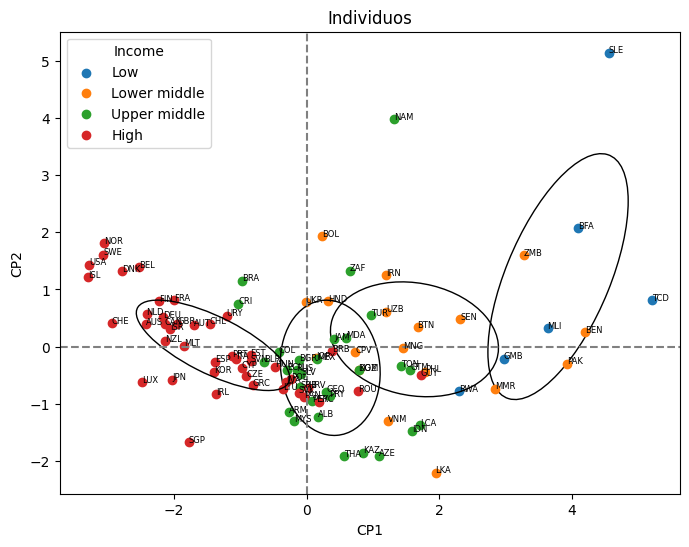

In [29]:
# Representación de los individuos
# Componentes 1 y 2 (coloreados por Income)
fig, ax = plt.subplots(figsize=(8, 6))

groups = datos["Income"].astype("category")

for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord.loc[ix, "CP1"],
               ind_coord.loc[ix, "CP2"],
               label=g)

    # elipse por grupo
    x = ind_coord.loc[ix, "CP1"]
    y = ind_coord.loc[ix, "CP2"]
    if len(x) > 2:  # para que la covarianza exista
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x.mean(), y.mean()), width, height,
                          angle=theta, edgecolor="black", fc="None", lw=1)
        ax.add_patch(ellipse)

# etiquetas de los individuos
for i, label in enumerate(ind_coord.index):
    ax.text(ind_coord["CP1"].iloc[i], ind_coord["CP2"].iloc[i],
            label, fontsize=6)

ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")
ax.set_xlabel("CP1")
ax.set_ylabel("CP2")
ax.set_title("Individuos")
ax.legend(title="Income")
plt.show()


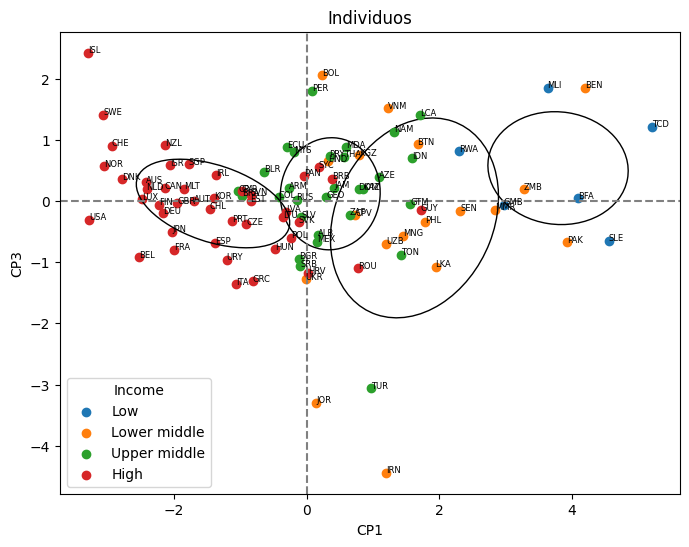

In [30]:
# Componentes 1 y 3
fig, ax = plt.subplots(figsize=(8, 6))

groups = datos["Income"].astype("category")

for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord.loc[ix, "CP1"],
               ind_coord.loc[ix, "CP3"],
               label=g)

    # elipse por grupo
    x = ind_coord.loc[ix, "CP1"]
    y = ind_coord.loc[ix, "CP3"]
    if len(x) > 2:
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x.mean(), y.mean()), width, height,
                          angle=theta, edgecolor="black", fc="None", lw=1)
        ax.add_patch(ellipse)

# etiquetas de los individuos
for i, label in enumerate(ind_coord.index):
    ax.text(ind_coord["CP1"].iloc[i], ind_coord["CP3"].iloc[i],
            label, fontsize=6)

ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")
ax.set_xlabel("CP1")
ax.set_ylabel("CP3")
ax.set_title("Individuos")
ax.legend(title="Income")
plt.show()


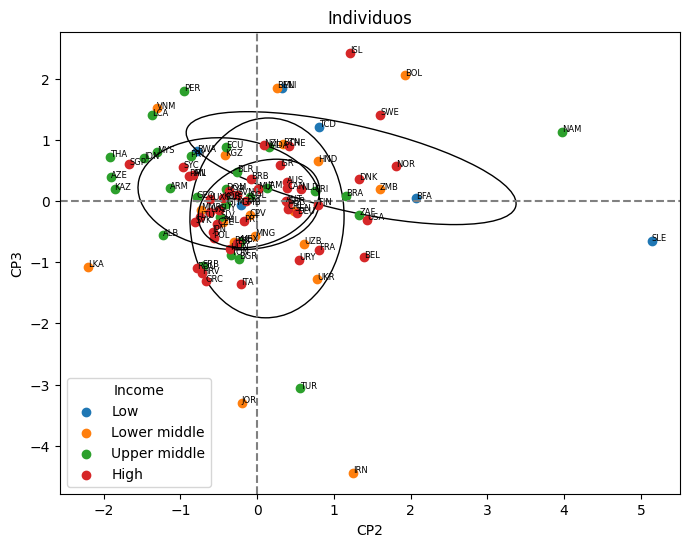

In [31]:
# Componentes 2 y 3
fig, ax = plt.subplots(figsize=(8, 6))

groups = datos["Income"].astype("category")

for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord.loc[ix, "CP2"],
               ind_coord.loc[ix, "CP3"],
               label=g)

    # elipse por grupo
    x = ind_coord.loc[ix, "CP2"]
    y = ind_coord.loc[ix, "CP3"]
    if len(x) > 2:
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x.mean(), y.mean()), width, height,
                          angle=theta, edgecolor="black", fc="None", lw=1)
        ax.add_patch(ellipse)

# etiquetas de los individuos
for i, label in enumerate(ind_coord.index):
    ax.text(ind_coord["CP2"].iloc[i], ind_coord["CP3"].iloc[i],
            label, fontsize=6)

ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")
ax.set_xlabel("CP2")
ax.set_ylabel("CP3")
ax.set_title("Individuos")
ax.legend(title="Income")
plt.show()


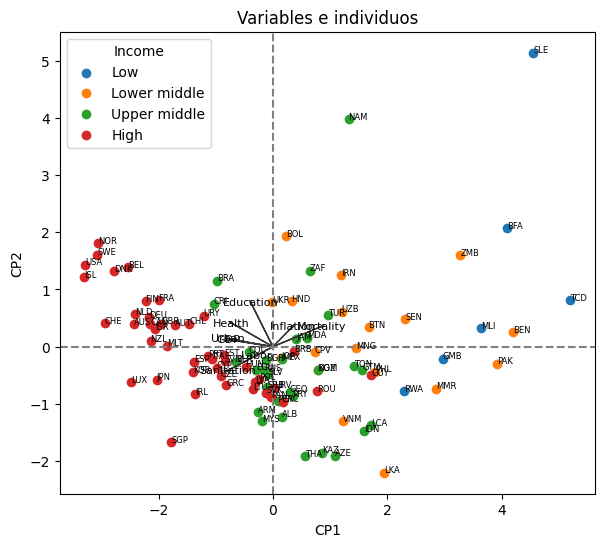

In [32]:
# Representación simultánea de variables e individuos
# Componentes 1 y 2
fig, ax = plt.subplots(figsize=(8, 6))

# Individuos coloreados por Income
groups = datos["Income"].astype("category")
for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord.loc[ix, "CP1"],
               ind_coord.loc[ix, "CP2"],
               label=g)

# Etiquetas de individuos
for i, label in enumerate(ind_coord.index):
    ax.text(ind_coord["CP1"].iloc[i], ind_coord["CP2"].iloc[i],
            label, fontsize=6)

# Variables (flechas en gris oscuro)
for i, label in enumerate(var_cor.index):
    x, y = var_cor["CP1"].iloc[i], var_cor["CP2"].iloc[i]
    ax.arrow(0, 0, x, y,
             head_width=0.03, head_length=0.05,
             fc="#3c3c3c", ec="#3c3c3c")
    ax.text(x, y, label, fontsize=8, ha="center", va="center")

# Ejes
ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")

ax.set_xlabel("CP1")
ax.set_ylabel("CP2")
ax.set_title("Variables e individuos")
ax.legend(title="Income")
ax.set_aspect("equal", adjustable="box")

plt.show()


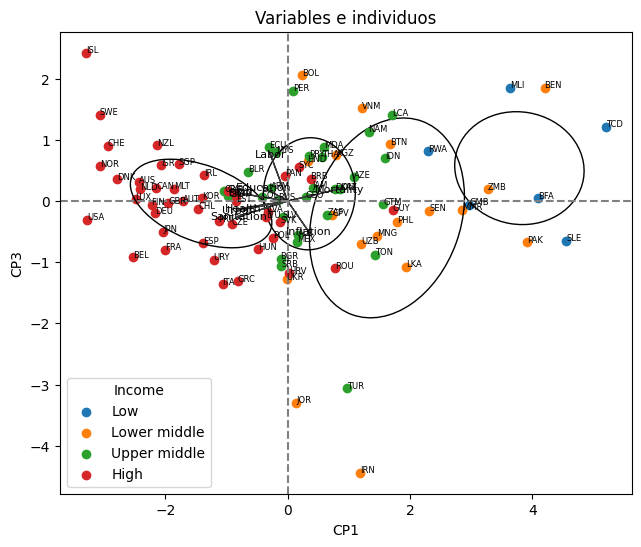

In [33]:
# Componentes 1 y 3
fig, ax = plt.subplots(figsize=(8, 6))

# Individuos coloreados por Income
groups = datos["Income"].astype("category")
for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord.loc[ix, "CP1"],
               ind_coord.loc[ix, "CP3"],
               label=g)

    # elipse por grupo
    x = ind_coord.loc[ix, "CP1"]
    y = ind_coord.loc[ix, "CP3"]
    if len(x) > 2:
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x.mean(), y.mean()), width, height,
                          angle=theta, edgecolor="black", fc="None", lw=1)
        ax.add_patch(ellipse)

# Etiquetas de individuos
for i, label in enumerate(ind_coord.index):
    ax.text(ind_coord["CP1"].iloc[i], ind_coord["CP3"].iloc[i],
            label, fontsize=6)

# Variables (flechas en gris oscuro)
for i, label in enumerate(var_cor.index):
    x, y = var_cor["CP1"].iloc[i], var_cor["CP3"].iloc[i]
    ax.arrow(0, 0, x, y,
             head_width=0.03, head_length=0.05,
             fc="#3c3c3c", ec="#3c3c3c")
    ax.text(x, y, label, fontsize=8, ha="center", va="center")

# Ejes
ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")

ax.set_xlabel("CP1")
ax.set_ylabel("CP3")
ax.set_title("Variables e individuos")
ax.legend(title="Income")
ax.set_aspect("equal", adjustable="box")

plt.show()


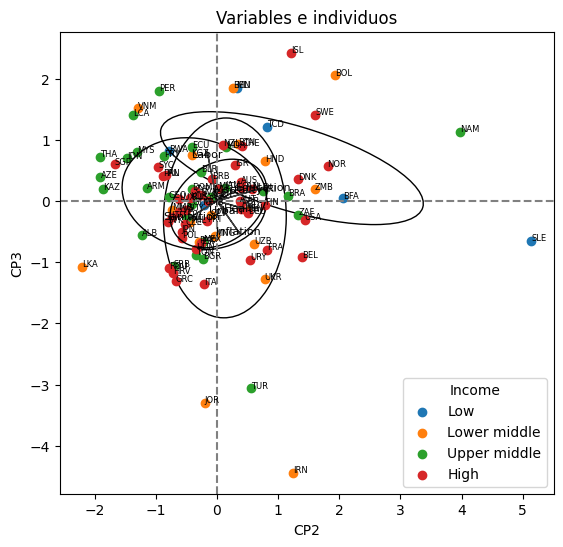

In [34]:
# Componentes 2 y 3
fig, ax = plt.subplots(figsize=(8, 6))

# Individuos coloreados por Income
groups = datos["Income"].astype("category")
for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord.loc[ix, "CP2"],
               ind_coord.loc[ix, "CP3"],
               label=g)

    # elipse por grupo
    x = ind_coord.loc[ix, "CP2"]
    y = ind_coord.loc[ix, "CP3"]
    if len(x) > 2:
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x.mean(), y.mean()), width, height,
                          angle=theta, edgecolor="black", fc="None", lw=1)
        ax.add_patch(ellipse)

# Etiquetas de individuos
for i, label in enumerate(ind_coord.index):
    ax.text(ind_coord["CP2"].iloc[i], ind_coord["CP3"].iloc[i],
            label, fontsize=6)

# Variables (flechas en gris oscuro)
for i, label in enumerate(var_cor.index):
    x, y = var_cor["CP2"].iloc[i], var_cor["CP3"].iloc[i]
    ax.arrow(0, 0, x, y,
             head_width=0.03, head_length=0.05,
             fc="#3c3c3c", ec="#3c3c3c")
    ax.text(x, y, label, fontsize=8, ha="center", va="center")

# Ejes
ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")

ax.set_xlabel("CP2")
ax.set_ylabel("CP3")
ax.set_title("Variables e individuos")
ax.legend(title="Income")
ax.set_aspect("equal", adjustable="box")

plt.show()


In [35]:
# Validación cruzada (criterio GCV)
def estim_ncp_gcv(X, ncp_min=0, ncp_max=None, scale=True):
    X = X.copy().astype(float)
    n, p = X.shape
    pquali = 0   # aquí no tratamos variables cualitativas

    if ncp_max is None:
        ncp_max = min(n - 2, p - 1)
    else:
        ncp_max = min(n - 2, p - 1, ncp_max)

    # centrar
    X = X - np.nanmean(X, axis=0)

    # escalar si corresponde
    if scale:
        et = np.nanstd(X, axis=0, ddof=1)
        X = X / et

    # SVD
    U, s, Vt = np.linalg.svd(X, full_matrices=False)
    d = s
    U = U[:, :ncp_max]
    Vt = Vt[:ncp_max, :]
    d = d[:ncp_max]

    crit = []

    rec = np.zeros_like(X)
    for q in range(max(ncp_min, 1), ncp_max + 1):
        if q == max(ncp_min, 1):
            if q == 1:
                rec = np.outer(U[:, 0] * d[0], Vt[0, :])
            else:
                rec = (U[:, :q] * d[:q]) @ Vt[:q, :]
        else:
            rec = rec + np.outer(U[:, q-1] * d[q-1], Vt[q-1, :])

        # --- método GCV ---
        num = n * p * (X - rec)
        den = (n - 1) * (p - pquali) - q * (n + p - pquali - q - 1)
        sol = (num / den) ** 2
        crit.append(np.nanmean(sol))

    # elegir ncp óptimo
    diffs = np.diff(crit)
    if np.any(diffs > 0):
        ncp = np.where(diffs > 0)[0][0] + max(ncp_min, 1)
    else:
        ncp = np.argmin(crit) + max(ncp_min, 1)

    return {"ncp": ncp, "criterion": crit}

gcv_res = pd.DataFrame({
    "ncp": list(range(1, 6)),  # en FactoMineR empieza en 1
    "GCV": [estim_ncp_gcv(X_scaled, ncp_max=k)["criterion"][-1]
            for k in range(1, 6)]
})

print(gcv_res)


   ncp       GCV
0    1  0.771614
1    2  0.784181
2    3  0.800950
3    4  0.774641
4    5  0.850020


In [36]:
# Construcción de indicadores
def indicadores(acp, k, alpha=3):
    f = pd.DataFrame(
        acp.transform(X_scaled)[:, :k],
        index=datos.index
    )
    for j in range(k):
        Q1, Q3 = f.iloc[:, j].quantile([0.25, 0.75])
        RIC = Q3 - Q1
        a = min(f.iloc[:, j].min(), Q1 - alpha * RIC)
        b = max(Q3 + alpha * RIC, f.iloc[:, j].max())
        f.iloc[:, j] = (f.iloc[:, j] - a) / (b - a)
    f.columns = [f"I{i+1}" for i in range(k)]
    return f

# Primeras 3 componentes como indicadores
I = indicadores(acp, k=3)
print(I.head(10))  # primeras 10 filas


               I1        I2        I3
Country                              
ALB      0.517852  0.321057  0.472929
ARM      0.492730  0.329792  0.566428
AUS      0.366948  0.493683  0.577820
AUT      0.408931  0.491263  0.540258
AZE      0.571429  0.248261  0.588176
BEL      0.361031  0.600122  0.429128
BEN      0.752715  0.478896  0.765728
BFA      0.746166  0.672281  0.546186
BGR      0.501379  0.426577  0.425520
BLR      0.470701  0.423736  0.599104


In [37]:
# Primer indicador
# Individuos con los 5 valores mínimos
print(I.nsmallest(5, "I1"))


               I1        I2        I3
Country                              
ISL      0.316007  0.581245  0.835404
USA      0.317251  0.604630  0.503438
SWE      0.329251  0.622955  0.712496
NOR      0.329864  0.644541  0.609641
CHE      0.336945  0.495669  0.650632


In [38]:
# Individuos con los 5 valores máximos
print(I.nlargest(5, "I1"))


               I1        I2        I3
Country                              
TCD      0.810921  0.538154  0.688020
SLE      0.773226  1.000000  0.461867
BEN      0.752715  0.478896  0.765728
BFA      0.746166  0.672281  0.546186
PAK      0.736443  0.419666  0.458490


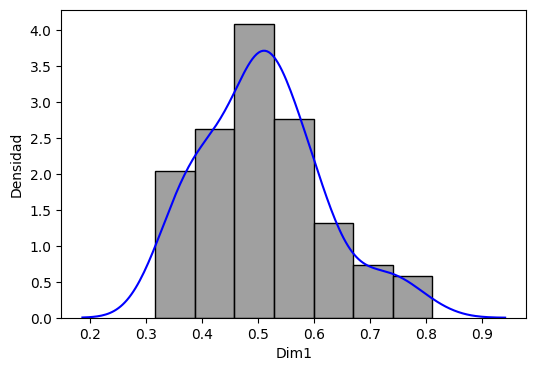

In [39]:
# Distribución del 1er indicador
import seaborn as sns

plt.figure(figsize=(6,4))
sns.histplot(I["I1"], bins=7, stat="density", color="gray", edgecolor="black")
sns.kdeplot(I["I1"], color="blue")
plt.ylabel("Densidad")
plt.xlabel("Dim1")
plt.show()


In [40]:
# Datos atípicos

# ACP con todas las componentes
acp_full = PCA(n_components=X.shape[1])
acp_full.fit(X_scaled)

# Primeras componentes

# Estadística d2^2
def d12(acp, p1, alpha=0.05):
    # Componentes principales
    F = acp.transform(X_scaled)
    # componentes estandarizadas
    F1 = (F - F.mean(axis=0)) / F.std(axis=0, ddof=1)
    # distancia
    d1i2 = np.sum(F1[:, :p1]**2, axis=1)
    # cuantil empírico
    cuantil = np.quantile(d1i2, 1-alpha)
    # Identificación de atípicos
    return pd.DataFrame({
        "Observación": np.arange(1, F.shape[0]+1),
        "d12": d1i2,
        "Cuantil": cuantil,
        "Atípico": d1i2 > cuantil
    }, index=datos.index)

# Considerando las tres primeras componentes
est_d12 = d12(acp_full, p1=3, alpha=0.05)

# Atípicos
atipicos = est_d12[est_d12["Atípico"] == True]
print(atipicos)


         Observación        d12   Cuantil  Atípico
Country                                           
IRN               42  20.739098  9.831947     True
ISL               43  10.028268  9.831947     True
JOR               47  10.558486  9.831947     True
NAM               64  14.456483  9.831947     True
SLE               80  27.615654  9.831947     True


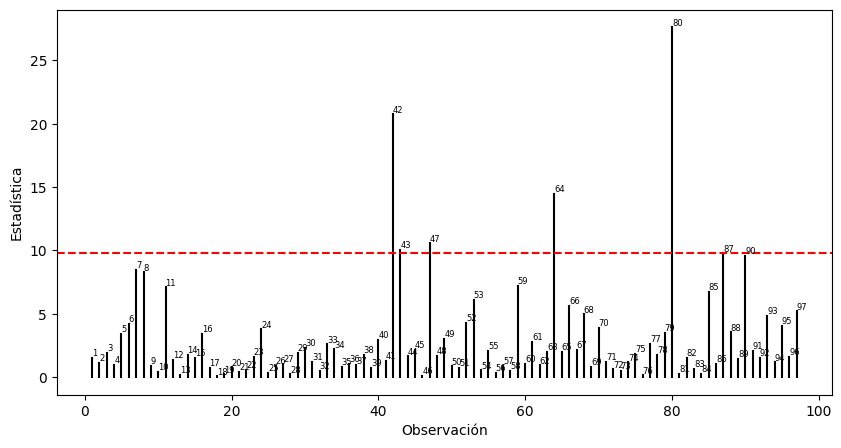

In [41]:
# Gráfico de la estadística d12
fig, ax = plt.subplots(figsize=(10, 5))

# segmentos verticales
for i in range(len(est_d12)):
    ax.plot([est_d12["Observación"].iloc[i], est_d12["Observación"].iloc[i]],
            [0, est_d12["d12"].iloc[i]], color="black")

# línea de cuantil
ax.axhline(y=est_d12["Cuantil"].iloc[0], linestyle="--", color="red")

# etiquetas de observaciones
for i in range(len(est_d12)):
    ax.text(est_d12["Observación"].iloc[i],
            est_d12["d12"].iloc[i],
            str(est_d12["Observación"].iloc[i]),
            fontsize=6, va="bottom")

ax.set_ylabel("Estadística")
ax.set_xlabel("Observación")
plt.show()


In [42]:
# Últimas componentes

# Estadística d2^2
def d22(acp, q, alpha=0.05):
    # Componentes principales
    F = acp.transform(X_scaled)
    # componentes estandarizadas
    F1 = (F - F.mean(axis=0)) / F.std(axis=0, ddof=1)
    p = F.shape[1]  # número de componentes
    # distancia usando las últimas q componentes
    d2i2 = np.sum(F1[:, p-q:p]**2, axis=1)
    # cuantil empírico
    cuantil = np.quantile(d2i2, 1-alpha)
    # Identificación de atípicos
    return pd.DataFrame({
        "Observación": np.arange(1, F.shape[0]+1),
        "d22": d2i2,
        "Cuantil": cuantil,
        "Atípico": d2i2 > cuantil
    }, index=datos.index)

# Considerando la última componente
est_d22 = d22(acp_full, q=1, alpha=0.05)

# Atípicos
atipicos_d22 = est_d22[est_d22["Atípico"] == True]
print(atipicos_d22)


         Observación        d22   Cuantil  Atípico
Country                                           
DOM               25   6.375981  5.453668     True
MLI               59   8.146793  5.453668     True
MNG               62   5.798974  5.453668     True
NAM               64   7.123086  5.453668     True
PAK               68  12.330255  5.453668     True


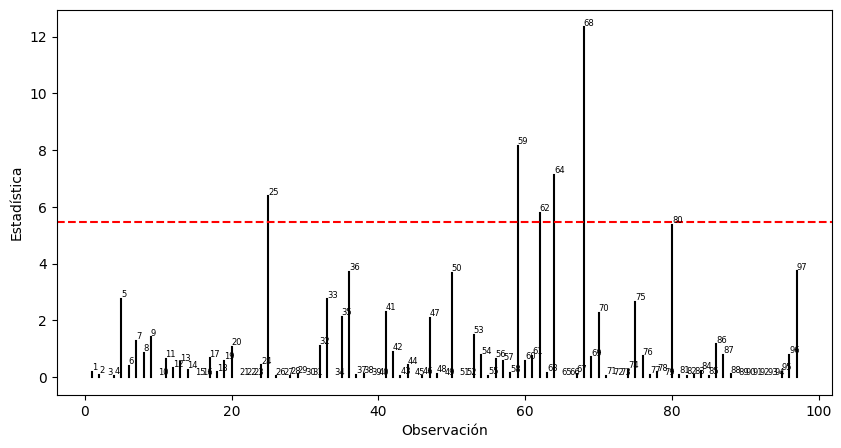

In [43]:
# Gráfico de la estadística d22
fig, ax = plt.subplots(figsize=(10, 5))

# segmentos verticales
for i in range(len(est_d22)):
    ax.plot([est_d22["Observación"].iloc[i], est_d22["Observación"].iloc[i]],
            [0, est_d22["d22"].iloc[i]], color="black")

# línea de cuantil
ax.axhline(y=est_d22["Cuantil"].iloc[0], linestyle="--", color="red")

# etiquetas de observaciones
for i in range(len(est_d22)):
    ax.text(est_d22["Observación"].iloc[i],
            est_d22["d22"].iloc[i],
            str(est_d22["Observación"].iloc[i]),
            fontsize=6, va="bottom")

ax.set_ylabel("Estadística")
ax.set_xlabel("Observación")
plt.show()


In [ ]:
# Considerando las dos últimas componentes
est_d22 = d22(acp_full, q=2, alpha=0.05)

# Atípicos
atipicos_d22 = est_d22[est_d22["Atípico"] == True]
print(atipicos_d22)


         Observación        d22   Cuantil  Atípico
Country                                           
IRL               41   8.234900  6.839705     True
LUX               55  16.670948  6.839705     True
MLI               59   8.522531  6.839705     True
NAM               64   7.189303  6.839705     True
PAK               68  12.819153  6.839705     True


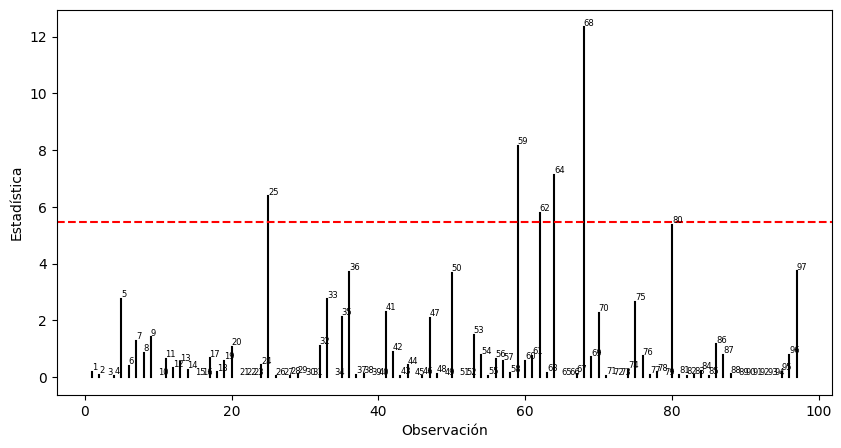

In [44]:
# Gráfico de la estadística d22 (dos últimas componentes)
fig, ax = plt.subplots(figsize=(10, 5))

# segmentos verticales
for i in range(len(est_d22)):
    ax.plot([est_d22["Observación"].iloc[i], est_d22["Observación"].iloc[i]],
            [0, est_d22["d22"].iloc[i]], color="black")

# línea de cuantil
ax.axhline(y=est_d22["Cuantil"].iloc[0], linestyle="--", color="red")

# etiquetas de observaciones
for i in range(len(est_d22)):
    ax.text(est_d22["Observación"].iloc[i],
            est_d22["d22"].iloc[i],
            str(est_d22["Observación"].iloc[i]),
            fontsize=6, va="bottom")

ax.set_ylabel("Estadística")
ax.set_xlabel("Observación")
plt.show()


# ACP robusto

In [45]:
# ACP robusto
from sklearn.covariance import MinCovDet
Xnum = datos.select_dtypes(include=[np.number]).to_numpy()

mcd = MinCovDet().fit(Xnum)
Sigma = mcd.covariance_                    # covarianza robusta (MVE)
mu = mcd.location_                         # centro robusto
sd_rob = np.sqrt(np.diag(Sigma))           # desviaciones robustas
R_rob = Sigma / np.outer(sd_rob, sd_rob)   # correlación robusta

# autovalores y autovectores de la correlación robusta
eigvals, eigvecs = np.linalg.eigh(R_rob)
order = np.argsort(eigvals)[::-1]
eigvals = eigvals[order]
eigvecs = eigvecs[:, order]

# puntuaciones (scores) sobre variables estandarizadas con escala robusta
Zr = (Xnum - mu) / sd_rob
scores = Zr @ eigvecs

acp_r = {
    "eigvals": eigvals,
    "eigvecs": eigvecs,
    "scores": pd.DataFrame(scores, index=datos.index,
                           columns=[f"CP{i+1}" for i in range(scores.shape[1])])
}


In [46]:
# Valores propios
vals = acp_r["eigvals"]
v_propios = pd.DataFrame({
    "v. propio": vals,
    "inercia": vals / vals.sum() * 100,
    "iner. acum.": np.cumsum(vals) / vals.sum() * 100
})
print(v_propios)


   v. propio    inercia  iner. acum.
0   3.877197  48.464969    48.464969
1   1.379308  17.241352    65.706320
2   0.857777  10.722211    76.428531
3   0.673371   8.417137    84.845668
4   0.443694   5.546179    90.391848
5   0.400755   5.009435    95.401283
6   0.235653   2.945668    98.346950
7   0.132244   1.653050   100.000000


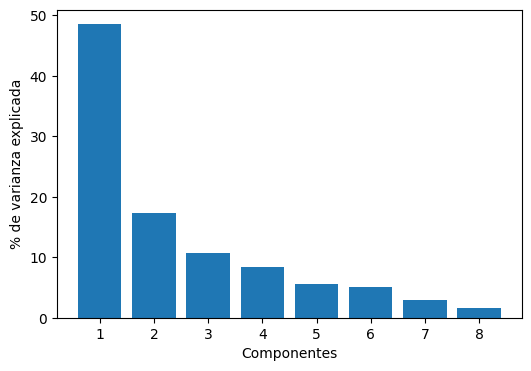

In [47]:
# Histograma de valores propios (Scree Plot)
vals = acp_r["eigvals"]
perc = vals / vals.sum() * 100

plt.figure(figsize=(6,4))
plt.bar(range(1, len(perc)+1), perc)
plt.xticks(range(1, len(perc)+1))
plt.xlabel("Componentes")
plt.ylabel("% de varianza explicada")
plt.show()


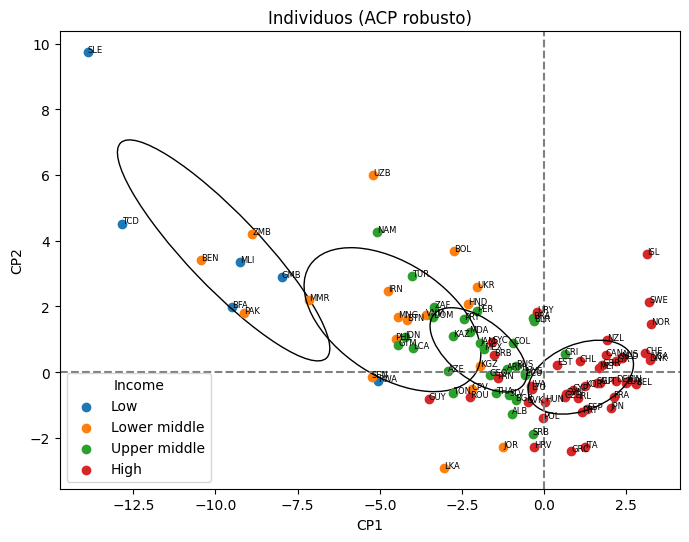

In [48]:
# Gráfico de las componentes 1 y 2 (ACP robusto)
fig, ax = plt.subplots(figsize=(8, 6))

ind_coord_r = acp_r["scores"]

# Individuos coloreados por Income
groups = datos["Income"].astype("category")
for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord_r.loc[ix, "CP1"],
               ind_coord_r.loc[ix, "CP2"],
               label=g)

    # elipse por grupo
    x = ind_coord_r.loc[ix, "CP1"]
    y = ind_coord_r.loc[ix, "CP2"]
    if len(x) > 2:
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x.mean(), y.mean()), width, height,
                          angle=theta, edgecolor="black", fc="None", lw=1)
        ax.add_patch(ellipse)

# Etiquetas de individuos
for i, label in enumerate(ind_coord_r.index):
    ax.text(ind_coord_r["CP1"].iloc[i], ind_coord_r["CP2"].iloc[i],
            label, fontsize=6)

# Ejes
ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")

ax.set_xlabel("CP1")
ax.set_ylabel("CP2")
ax.set_title("Individuos (ACP robusto)")
ax.legend(title="Income")
ax.set_aspect("equal", adjustable="box")

plt.show()


In [49]:
# ACP mediante Projection-Pursuit
from sklearn.decomposition import PCA
from statsmodels import robust

# Seleccionar solo variables numéricas
Xnum = datos.select_dtypes(include=[np.number])

# centrar con la mediana y escalar con MAD
medianas = Xnum.median()
mads = Xnum.apply(robust.mad)
Xpp = (Xnum - medianas) / mads

# PCA clásico sobre los datos transformados → projection pursuit PCA
pca_pp = PCA(n_components=6)
scores_pp = pca_pp.fit_transform(Xpp)

# DataFrame de scores con los mismos nombres de fila
acp_pp = {
    "scores": pd.DataFrame(scores_pp,
                           index=datos.index,
                           columns=[f"CP{i+1}" for i in range(scores_pp.shape[1])]),
    "eigvals": pca_pp.explained_variance_,
    "loadings": pca_pp.components_.T
}


In [50]:
# Valores propios
vals = acp_pp["eigvals"]
v_propios = pd.DataFrame({
    "v. propio": vals,
    "inercia": vals / vals.sum() * 100,
    "iner. acum.": np.cumsum(vals) / vals.sum() * 100
})
print(v_propios)


   v. propio    inercia  iner. acum.
0  18.681584  63.491487    63.491487
1   4.287059  14.570056    78.061543
2   2.900528   9.857773    87.919316
3   1.868131   6.349054    94.268370
4   1.105613   3.757550    98.025920
5   0.580848   1.974080   100.000000


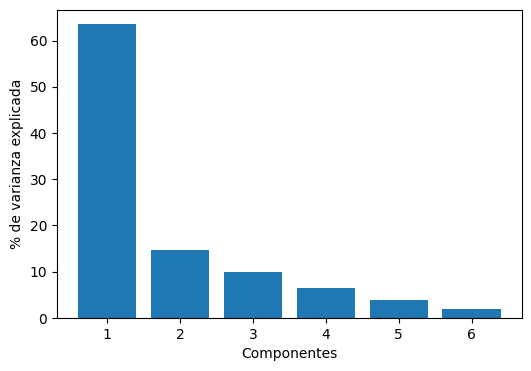

In [51]:
# Histograma de valores propios (Scree Plot)
vals = acp_pp["eigvals"]
perc = vals / vals.sum() * 100

plt.figure(figsize=(6,4))
plt.bar(range(1, len(perc)+1), perc)
plt.xticks(range(1, len(perc)+1))
plt.xlabel("Componentes")
plt.ylabel("% de varianza explicada")
plt.show()


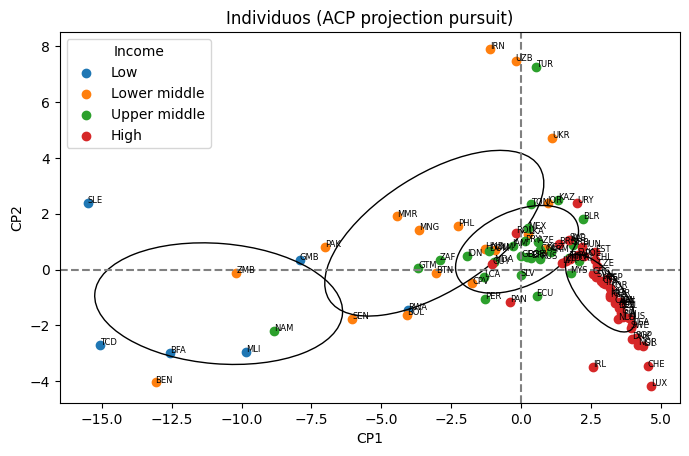

In [52]:
# Gráfico de las componentes 1 y 2 (ACP projection pursuit)
fig, ax = plt.subplots(figsize=(8, 6))

ind_coord_pp = acp_pp["scores"]

# Individuos coloreados por Income
groups = datos["Income"].astype("category")
for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord_pp.loc[ix, "CP1"],
               ind_coord_pp.loc[ix, "CP2"],
               label=g)

    # elipse por grupo
    x = ind_coord_pp.loc[ix, "CP1"]
    y = ind_coord_pp.loc[ix, "CP2"]
    if len(x) > 2:
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x.mean(), y.mean()), width, height,
                          angle=theta, edgecolor="black", fc="None", lw=1)
        ax.add_patch(ellipse)

# Etiquetas de individuos
for i, label in enumerate(ind_coord_pp.index):
    ax.text(ind_coord_pp["CP1"].iloc[i], ind_coord_pp["CP2"].iloc[i],
            label, fontsize=6)

# Ejes
ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")

ax.set_xlabel("CP1")
ax.set_ylabel("CP2")
ax.set_title("Individuos (ACP projection pursuit)")
ax.legend(title="Income")
ax.set_aspect("equal", adjustable="box")

plt.show()


In [53]:
# Análisis de componentes principales con kernels
from sklearn.decomposition import KernelPCA
from scipy.stats import kendalltau

# Estandarización
Z = (datos.select_dtypes(include=[np.number]) -
     datos.select_dtypes(include=[np.number]).mean()) / \
     datos.select_dtypes(include=[np.number]).std()

# ACP con kernels (RBF kernel)
kpca = KernelPCA(n_components=Z.shape[1], kernel="rbf", fit_inverse_transform=True)
scores_k = kpca.fit_transform(Z)

# Valores propios (desviaciones estándar de componentes)
sdev = np.sqrt(np.maximum(kpca.eigenvalues_, 0))

# Cargas (correlaciones Kendall entre variables originales y componentes)
loadings = pd.DataFrame(index=Z.columns, columns=[f"CP{i+1}" for i in range(scores_k.shape[1])])
for j, var in enumerate(Z.columns):
    for k in range(scores_k.shape[1]):
        loadings.iloc[j, k] = kendalltau(Z.iloc[:, j], scores_k[:, k])[0]

# Armar objeto estilo princomp
acp_k = {
    "sdev": sdev,
    "loadings": loadings,
    "scores": pd.DataFrame(scores_k, index=datos.index,
                           columns=[f"CP{i+1}" for i in range(scores_k.shape[1])]),
    "center": np.zeros(Z.shape[1]),
    "scale": np.ones(Z.shape[1])
}


In [54]:
# Valores propios
vals = acp_k["sdev"]**2
v_propios = pd.DataFrame({
    "v. propio": vals,
    "inercia": vals / vals.sum() * 100,
    "iner. acum.": np.cumsum(vals) / vals.sum() * 100
})

print(v_propios.head(Z.shape[1]))


   v. propio    inercia  iner. acum.
0  11.473709  28.530552    28.530552
1   9.338979  23.222328    51.752880
2   4.939881  12.283519    64.036399
3   3.804575   9.460466    73.496865
4   3.443334   8.562204    82.059068
5   2.644910   6.576840    88.635908
6   2.363946   5.878193    94.514101
7   2.206183   5.485899   100.000000


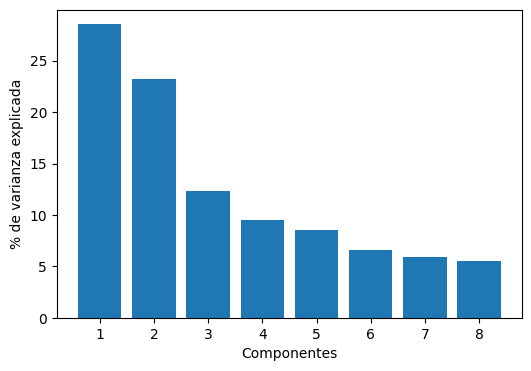

In [55]:
# Histograma de valores propios (Scree Plot)
vals = acp_k["sdev"]**2
perc = vals / vals.sum() * 100

plt.figure(figsize=(6,4))
plt.bar(range(1, Z.shape[1]+1), perc)
plt.xticks(range(1, Z.shape[1]+1))
plt.xlabel("Componentes")
plt.ylabel("% de varianza explicada")
plt.show()


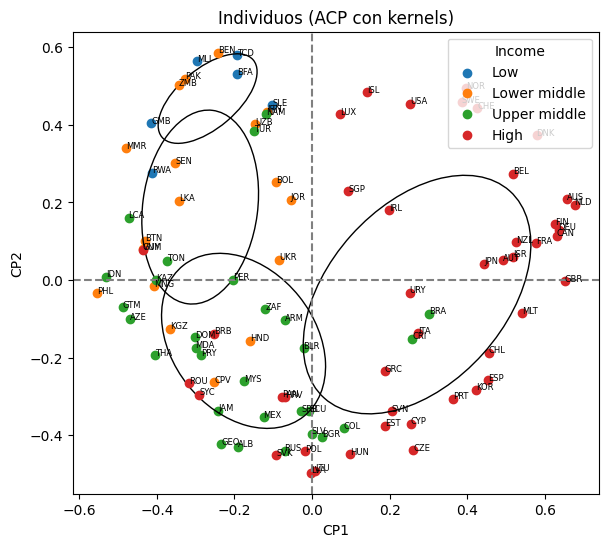

In [56]:
# Gráfico de las componentes 1 y 2 (ACP con kernels)
fig, ax = plt.subplots(figsize=(8, 6))

ind_coord_k = acp_k["scores"]

# Individuos coloreados por Income
groups = datos["Income"].astype("category")
for g in groups.cat.categories:
    ix = groups == g
    ax.scatter(ind_coord_k.loc[ix, "CP1"],
               ind_coord_k.loc[ix, "CP2"],
               label=g)

    # elipse por grupo
    x = ind_coord_k.loc[ix, "CP1"]
    y = ind_coord_k.loc[ix, "CP2"]
    if len(x) > 2:
        cov = np.cov(x, y)
        vals, vecs = np.linalg.eigh(cov)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        theta = np.degrees(np.arctan2(*vecs[:, 0][::-1]))
        width, height = 2 * np.sqrt(vals)
        from matplotlib.patches import Ellipse
        ellipse = Ellipse((x.mean(), y.mean()), width, height,
                          angle=theta, edgecolor="black", fc="None", lw=1)
        ax.add_patch(ellipse)

# Etiquetas de individuos
for i, label in enumerate(ind_coord_k.index):
    ax.text(ind_coord_k["CP1"].iloc[i], ind_coord_k["CP2"].iloc[i],
            label, fontsize=6)

# Ejes
ax.axhline(0, linestyle="--", color="gray")
ax.axvline(0, linestyle="--", color="gray")

ax.set_xlabel("CP1")
ax.set_ylabel("CP2")
ax.set_title("Individuos (ACP con kernels)")
ax.legend(title="Income")
ax.set_aspect("equal", adjustable="box")

plt.show()
